# Imports and settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil

# --- Color Constants ---
GREEN = '\033[92m'
YELLOW = '\033[93m'
RED = '\033[91m'
RESET_COLORS = '\033[0m'

# --- Paths Configuration ---
# Notebook is in root, so we enter 'data' directly
DATA_DIR = 'data'
PLOTS_DIR = 'plots'

RAW_DATA_NPY = os.path.join(DATA_DIR, 'Dropbox_Dataset.npy')
CLEAN_DATA_NPY = os.path.join(DATA_DIR, 'dataset_clean.npy')

# --- Plot File Paths ---
USER_DIST_PLOT = os.path.join(PLOTS_DIR, 'user_rating_dist.png')
FILTERED_USER_DIST_PLOT = os.path.join(PLOTS_DIR, 'filtered_user_dist.png')
COMPARISON_PLOT = os.path.join(PLOTS_DIR, 'original_vs_filtered.png')
MOVIE_DIST_PLOT = os.path.join(PLOTS_DIR, 'movie_rating_dist.png')

# --- Analysis Constants ---
TOP_N_THRESHOLD = 10000
MIN_RATINGS_N = 10

In [2]:
# %matplotlib tk

## Initializations and Directory Setup

In [3]:
try:
    # 1. Load the raw strings
    raw_dataset = np.load(RAW_DATA_NPY, allow_pickle=True)
    print(f"{GREEN}Loaded {len(raw_dataset)} raw strings.{RESET_COLORS}")

    # 2. Split the strings by comma
    # This creates a list of lists: [['user', 'movie', 'rating', 'date'], [...]]
    split_data = [line.split(',') for line in raw_dataset]

    # 3. Create the DataFrame
    df = pd.DataFrame(split_data, columns=['user', 'movie', 'rating', 'date'])

    # 4. Clean up Data Types (Very important for ML!)
    # Convert 'rating' to numeric so we can do math on it later
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

    print(f'\n{YELLOW}DataFrame info:{RESET_COLORS}')
    print(f'- Total rows: {len(df)}')
    print(f'- Unique users: {df["user"].nunique()}')
    print(f'- Unique movies: {df["movie"].nunique()}')
    print(f'- Average Rating: {df["rating"].mean():.2f}')
    print('-' * 30)

    # Show the first 5 rows to confirm it looks like a table now
    print(df.head())

except Exception as e:
    print(f"{RED}Error during parsing: {e}{RESET_COLORS}")

Loaded 4669820 raw strings.

DataFrame info:
- Total rows: 4669820
- Unique users: 1499238
- Unique movies: 351109
- Average Rating: 6.76
------------------------------
        user      movie  rating             date
0  ur4592644  tt0120884      10  16 January 2005
1  ur3174947  tt0118688       3  16 January 2005
2  ur3780035  tt0387887       8  16 January 2005
3  ur4592628  tt0346491       1  16 January 2005
4  ur3174947  tt0094721       8  16 January 2005


# User Rating Distribution Analysis

## Binning and Statistics

In [4]:
# Get the number of ratings per user
ratings_per_user = df.groupby('user').size()

# Slice the possible rating counts in logical bins
bins = [0, 1, 2, 3, 10, 20, 100, float('inf')]
labels = ['1', '2', '3', '4-10', '11-20', '21-100', '100+']

# Put each user in the respective bin
user_bins = pd.cut(ratings_per_user, bins=bins, labels=labels, right=True)
bin_counts = user_bins.value_counts().sort_index()

print(f'\n{YELLOW}Percentage of users in each rating count bin:{RESET_COLORS}')
print((bin_counts / len(ratings_per_user) * 100).round(2))


Percentage of users in each rating count bin:
1         71.34
2         12.80
3          5.08
4-10       7.87
11-20      1.63
21-100     1.08
100+       0.21
Name: count, dtype: float64


In [5]:
### Visualizing User Distribution

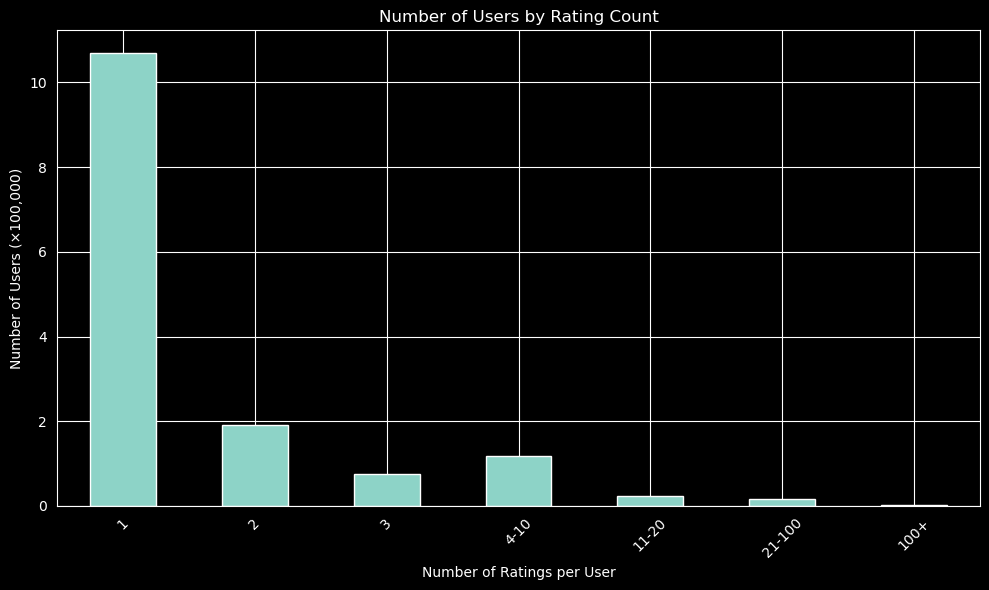

In [6]:
plt.figure(figsize=(10, 6))
(bin_counts / 100000).plot(kind='bar')
plt.title('Number of Users by Rating Count')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users (×100,000)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(USER_DIST_PLOT)
plt.show()

# Dimensionality Reduction: Lonely Ratings Analysis

## Identifying Single Ratings

In [7]:
# Count movie ratings
movie_rating_counts = df['movie'].value_counts()

# Find movies and users with exactly one rating
movies_rated_once = movie_rating_counts[movie_rating_counts == 1].index.to_list()
one_rating_users = ratings_per_user[ratings_per_user == 1].index.to_list()

# Identify "lonely ratings" (intersection)
lonely_ratings_mask = (df['user'].isin(one_rating_users)) & (df['movie'].isin(movies_rated_once))
lonely_ratings = df[lonely_ratings_mask]

print(f'\n{GREEN}Movies rated exactly once: {len(movies_rated_once)}{RESET_COLORS}')
print(f'{GREEN}Users with only one rating: {len(one_rating_users)}{RESET_COLORS}')
print(f'{GREEN}Lonely ratings count: {len(lonely_ratings)}{RESET_COLORS}')


Movies rated exactly once: 151175
Users with only one rating: 1069533
Lonely ratings count: 25342


# Filtered Dataset Comparison

## Data Filtering and Re-binning

In [8]:
# Remove movies rated once
df_movies_multiple_ratings = df[~df['movie'].isin(movies_rated_once)]

# Repeat distribution for filtered dataset
ratings_per_user_filtered = df_movies_multiple_ratings.groupby('user').size()
user_bins_filtered = pd.cut(ratings_per_user_filtered, bins=bins, labels=labels, right=True)
bin_counts_filtered = user_bins_filtered.value_counts().sort_index()

# Comparison Table
comparison_df = pd.DataFrame({'Original': bin_counts, 'Filtered': bin_counts_filtered}).fillna(0)
print(f'\n{YELLOW}Comparison of user counts:{RESET_COLORS}')
print(comparison_df)


Comparison of user counts:
        Original  Filtered
1        1069533   1051259
2         191934    188568
3          76087     74657
4-10      117959    115897
11-20      24416     23869
21-100     16156     15794
100+        3153      3040


### Plotting Original vs Filtered Data

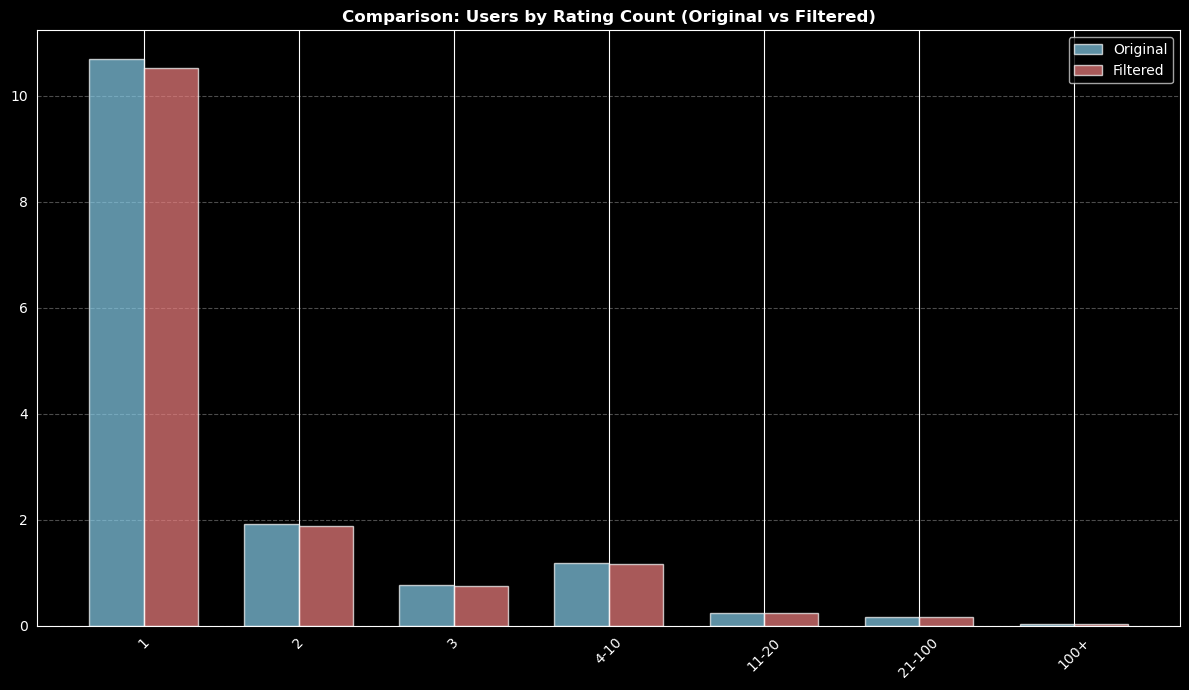

In [9]:
plt.figure(figsize=(12, 7))
x = np.arange(len(bin_counts.index))
width = 0.35

original_bars = plt.bar(x - width/2, bin_counts.values/100000, width, label='Original', color='skyblue', alpha=0.7)
filtered_bars = plt.bar(x + width/2, bin_counts_filtered.reindex(bin_counts.index, fill_value=0)/100000, width, label='Filtered', color='lightcoral', alpha=0.7)

plt.title('Comparison: Users by Rating Count (Original vs Filtered)', fontweight='bold')
plt.xticks(x, bin_counts.index, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

plt.savefig(COMPARISON_PLOT)
plt.show()

# Final Movie Distribution and Thresholding

## Movie Rating Distribution

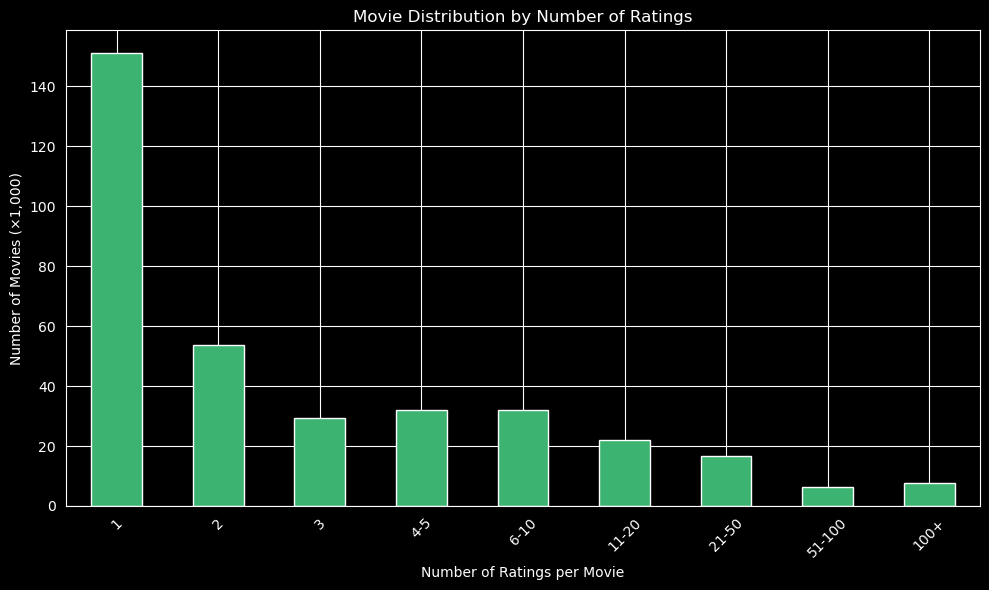

In [10]:
movie_bins = [0, 1, 2, 3, 5, 10, 20, 50, 100, float('inf')]
movie_labels = ['1', '2', '3', '4-5', '6-10', '11-20', '21-50', '51-100', '100+']

movie_rating_bins = pd.cut(movie_rating_counts, bins=movie_bins, labels=movie_labels, right=True)
movie_bin_counts = movie_rating_bins.value_counts().sort_index()

plt.figure(figsize=(10,6))
(movie_bin_counts / 1000).plot(kind='bar', color='mediumseagreen')
plt.title('Movie Distribution by Number of Ratings')
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Number of Movies (×1,000)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(MOVIE_DIST_PLOT)
plt.show()

## Top N Movie Filtering (R_min = 1)

In [11]:
df_users_multiple_ratings = df[~df['user'].isin(one_rating_users)]
movie_ratings_count_after_r1 = df_users_multiple_ratings['movie'].value_counts()
top_n_movies = movie_ratings_count_after_r1.nlargest(TOP_N_THRESHOLD).index

df_top_movies = df_users_multiple_ratings[df_users_multiple_ratings['movie'].isin(top_n_movies)]

print(f'\n{GREEN}Top {TOP_N_THRESHOLD} Movies filtering results:{RESET_COLORS}')
print(f'Remaining Ratings: {len(df_top_movies)}')
print(f'Minimum ratings in remaining movies: {df_top_movies.groupby("movie").size().min()}')


Top 10000 Movies filtering results:
Remaining Ratings: 2167588
Minimum ratings in remaining movies: 59


## Advanced Filtering (Users with ≥ N Ratings)

In [12]:
# Filter users by N ratings first
at_least_n_rating_users = ratings_per_user[ratings_per_user >= MIN_RATINGS_N].index.to_list()
df_users_filtered = df[df['user'].isin(at_least_n_rating_users)]

# Then take top movies
movie_ratings_count_after_r1_n = df_users_filtered['movie'].value_counts()
top_n_movies_second = movie_ratings_count_after_r1_n.nlargest(TOP_N_THRESHOLD).index
df_top_movies_second = df_users_filtered[df_users_filtered['movie'].isin(top_n_movies_second)]

print(f'\n{GREEN}Strict filtering (Users >= {MIN_RATINGS_N}) results:{RESET_COLORS}')
print(f'Unique users remaining: {df_top_movies_second["user"].nunique()}')
print(f'Total ratings: {len(df_top_movies_second)}')


Strict filtering (Users >= 10) results:
Unique users remaining: 48408
Total ratings: 1342376
